# 读取后台 DE 仿真结果（analysis_result_*.npz）

本 notebook 演示如何读取由后台脚本
`scripts/run_20260730_background.py` 生成的 `analysis_result_muon_events.<i>.npz`，
并参照原 `20260730.ipynb` 对延迟电子（DE）堆叠信号进行分析与画图。

后台脚本每个 muon 文件输出一份 `analysis_result_muon_events.<i>.npz`，包含字段：

| 字段 | 说明 |
|---|---|
| `de_st_cor` | 每个堆叠事件的 space-time correlation |
| `de_pattern` | pattern likelihood |
| `de_area` | 每个事件的总 PE（area） |
| `de_pe_by_area` | 每个事件各 PMT 通道的 PE (`N_evt × N_ch`) |
| `time_range_s` | 该 muon 文件的模拟时间窗 |
| `n_de` | 该文件保留的 DE 事件数 |
| `input_file` | 对应 muon 输入文件路径 |


In [2]:
# ============================================================
# 1) 导入 + 配置结果目录 + 读取所有 analysis_result_*.npz
# ============================================================
import os
from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt

# 后台脚本的输出目录（--out-dir 参数）
RESULT_DIR = Path("output/20260730")
if not RESULT_DIR.exists():
    # 若在项目根下运行，结果在 ./output/20260730
    RESULT_DIR = Path("../scripts/output/20260730")
RESULT_DIR = RESULT_DIR.resolve()
print("结果目录:", RESULT_DIR)
assert RESULT_DIR.exists(), f"未找到输出目录 {RESULT_DIR}，请先运行后台脚本。"

# 需要的数组键（取决于脚本保存的字段名，可用下面检查实际键名）
KEYS = ["de_st_cor", "de_pattern", "de_area", "de_pe_by_area"]

# 收集所有 analysis_result_*.npz
npz_files = sorted(glob.glob(str(RESULT_DIR / "analysis_result_*.npz")))
print(f"找到 {len(npz_files)} 个结果文件")
for f in npz_files:
    print(" ", Path(f).name)


结果目录: /home/leiyang/TPC_DE_SIm-test/scripts/output/20260730
找到 2 个结果文件
  analysis_result_muon_events.1.npz
  analysis_result_muon_events.2.npz


In [3]:
# ============================================================
# 2) 逐个加载 npz，合并所有文件的 DE 数组
#    使用 with np.load(...) 及时释放文件句柄，避免内存堆积
# ============================================================
parts = {k: [] for k in KEYS}
total_time = 0.0
n_per_file = []

for fp in npz_files:
    with np.load(fp, allow_pickle=False) as d:
        for k in KEYS:
            parts[k].append(d[k])
        total_time += float(d["time_range_s"])
        n_per_file.append(int(d["n_de"]))

# 合并成一个大的结构化数组
de = {k: np.concatenate(parts[k]) if len(parts[k]) > 1 else parts[k][0]
      for k in KEYS}

# 释放中间列表引用
del parts

print(f"合并后 DE 事件总数: {len(de['de_area'])}")
print(f"总模拟时间: {total_time:.3f} s")
print(f"每文件事件数: {n_per_file}")
print("de_pe_by_area shape:", de["de_pe_by_area"].shape)

# 方便后续使用的别名（与原 notebook 变量名一致）
st_cor   = de["de_st_cor"]
pattern  = de["de_pattern"]
DE_area  = de["de_area"]
DE_pe_by_area = de["de_pe_by_area"]


合并后 DE 事件总数: 14057470
总模拟时间: 13535.000 s
每文件事件数: [7021551, 7035919]
de_pe_by_area shape: (14057470, 56)


In [4]:
# ============================================================
# 3) 加载 PMT 几何布局（用于 pattern_plot），并复刻原 notebook 的绘图函数
# ============================================================
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid

# PMT 布局 dtype：与 relics_de_sim/constants.PMT_DTYPE 一致
PMT_DTYPE = np.dtype([
    ("ChannelID", "<i4"),
    ("x", "<f8"),
    ("y", "<f8"),
    ("z", "<f8"),
    ("rot_x", "<f8"),
    ("rot_y", "<f8"),
    ("rot_z", "<f8"),
])

# 定位 PMT 布局文件（自动搜索项目根，兼容 Windows/Linux/服务器）
def _find_pmt_layout():
    for cand in (Path.cwd(),
                 Path.cwd() / "TPC_DE_SIm-test",
                 Path.cwd().parent,
                 Path.cwd().parent / "TPC_DE_SIm-test"):
        p = cand / "LCE_info" / "topPMTs.txt"
        if p.exists():
            return cand / "LCE_info"
    raise FileNotFoundError("未找到 LCE_info/topPMTs.txt，请检查项目路径。")

_lce_dir = _find_pmt_layout()
pmt_top = np.loadtxt(_lce_dir / "topPMTs.txt", dtype=PMT_DTYPE)
print("pmt_top path:", _lce_dir / "topPMTs.txt", "| shape:", pmt_top.shape)


def pattern_plot(phe_pmt, electron=[], pos_recons=[], pmt_info=pmt_top,
                 title="", savefig=False):
    """绘制单个 DE 堆叠事件的 PMT 光斑（复刻原 notebook）。"""
    phe_pmt = np.asarray(phe_pmt)
    phe_pmt = np.nan_to_num(phe_pmt, nan=0.0)

    max_val = phe_pmt.max()
    if max_val <= 1:
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, max_val))
    else:
        try:
            norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
        except ValueError:
            norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    cmap = mpl.cm.viridis

    fig = plt.figure(figsize=(7, 6))
    grid = ImageGrid(fig, 111, (1, 1))

    for pmt_id in range(len(pmt_info)):
        pmt = pmt_info[pmt_id]
        if phe_pmt[pmt_id] < 0.1:
            pmt_color = 'white'
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
        grid[0].text(pmt['x'], pmt['y'], str(round(phe_pmt[pmt_id], 1)),
                     ha='center', va='center', fontsize=15)
        border = Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27), width=2.54,
                           height=2.54, angle=pmt['rot_z'],
                           rotation_point='center', fc='none', ec='black',
                           lw=1, alpha=1)
        grid[0].add_patch(border)
        grid[0].add_patch(Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27),
                                    width=2.54, height=2.54, angle=pmt['rot_z'],
                                    rotation_point='center', fc=pmt_color,
                                    alpha=1))
    if len(electron) > 0:
        grid[0].plot(electron['xd'] / 10, electron['yd'] / 10, 'ro',
                     markersize=12, label='Position')
    if len(pos_recons) > 0:
        grid[0].plot(pos_recons[0] / 10, pos_recons[0] / 10, 'b*',
                     markersize=12, label='Recon Position')
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend()
    grid[0].set_title(title)
    if savefig:
        plt.savefig(title + ".png")
    plt.show()
    return 0


pmt_top path: /home/leiyang/TPC_DE_SIm-test/LCE_info/topPMTs.txt | shape: (28,)


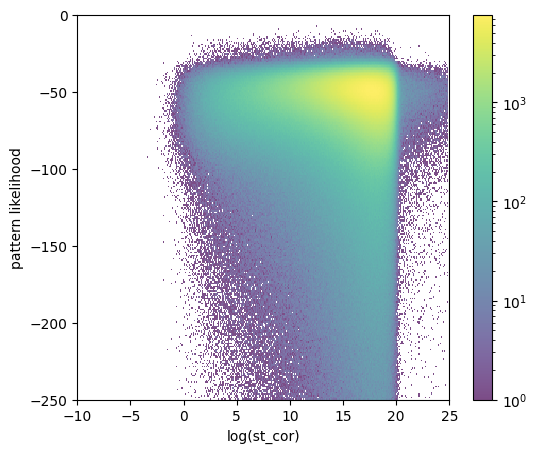

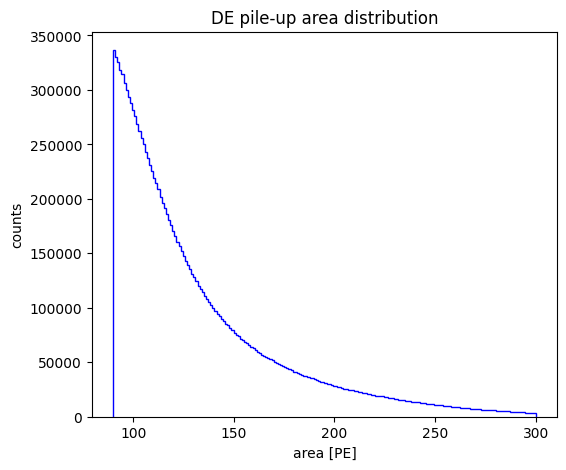

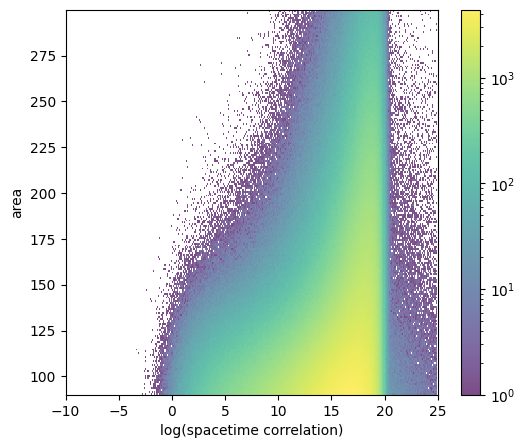

In [5]:
# ============================================================
# 4) DE 关键分布画图（对照原 notebook）
# ============================================================
from matplotlib.colors import LogNorm

# --- 4.1 log(st_cor) vs pattern likelihood 2D 直方图 ---
x_bins = np.arange(-10, 25, 0.1)
y_bins = np.arange(-250, 0, 1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), pattern, bins=(x_bins, y_bins),
              cmap='viridis', norm=LogNorm(), alpha=0.7)
ax.set_xlabel('log(st_cor)')
ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.ylim(-250, 0)
plt.show()

# --- 4.2 DE area 分布 ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(DE_area, bins=200, histtype='step', color='blue')
ax.set_xlabel('area [PE]')
ax.set_ylabel('counts')
ax.set_title('DE pile-up area distribution')
plt.show()

# --- 4.3 log(st_cor) vs DE area 2D ---
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), DE_area, bins=(x_bins, 200),
              cmap='viridis', norm=LogNorm(), alpha=0.7)
ax.set_xlabel('log(spacetime correlation)')
ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.show()


  0%|          | 0/14057470 [00:00<?, ?it/s]

100%|██████████| 14057470/14057470 [10:22<00:00, 22574.66it/s]


pattern_score: shape = (14057470,)
pattern_score: min = 3.020, max = 12.840, mean = 3.981


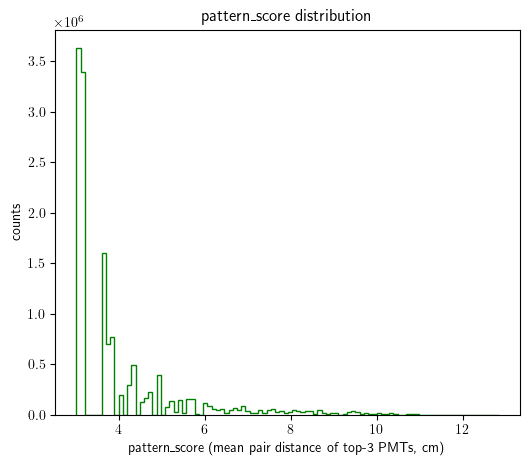

In [ ]:
# # ============================================================
# # 新定义的 pattern_score：
# #   对每个 DE 事件，选出 de_pe_by_area 中 PE 最大的 3 个 PMT，
# #   计算这 3 个 PMT 两两之间的平均距离（基于 pmt_top 的 x, y 位置）。
# # ============================================================
# import numpy as np

# # pmt_top 各 PMT 的坐标
# pmt_xy = np.stack([pmt_top["x"], pmt_top["y"]], axis=1)   # (N_pmt, 2)


# def pattern_score_one(pe_vec, pmt_xy=pmt_xy, n_top=3):
#     """对单个事件：取 PE 最大的 n_top 个 PMT，返回它们两两平均距离。"""
#     # 选出 PE 最大的 n_top 个 PMT 下标
#     top_idx = np.argsort(pe_vec[:28])[-n_top:]
#     idx3 = top_idx
#     # 只取多个PMT两两距离的平均（需要 n_top>=2）
#     if len(idx3) < 2:
#         return 0.0
#     pts = pmt_xy[idx3]                                   # 所选 PMT 的 (x, y)
#     # 两两欧氏距离矩阵，取上三角的平均
#     d = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(axis=2))
#     n = len(pts)
#     # 取严格上三角非零距离的平均
#     iu = np.triu_indices(n, k=1)
#     return float(d[iu].mean())

# from tqdm import tqdm
# # 对整个 DE 事件集合计算 pattern_score
# pattern_score = np.array([pattern_score_one(DE_pe_by_area[i]) for i in tqdm(range(len(DE_pe_by_area)))])

# print("pattern_score: shape =", pattern_score.shape)
# print("pattern_score: min = {:.3f}, max = {:.3f}, mean = {:.3f}".format(
#     pattern_score.min(), pattern_score.max(), pattern_score.mean()))

# # 展示分布
# fig, ax = plt.subplots(figsize=(6, 5))
# ax.hist(pattern_score, bins=100, histtype='step', color='green')
# ax.set_xlabel('pattern_score (mean pair distance of top-3 PMTs, cm)')
# ax.set_ylabel('counts')
# ax.set_title('pattern_score distribution')
# plt.show()


In [41]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os

# 确保能 import 包（在仓库根运行时通常为 '.'）
sys.path.append('/home/leiyang/TPC_DE_SIm-test')
from relics_de_sim.config import DESimConfig
from relics_de_sim.pipeline import Pipeline
import relics_de_sim as rds
importlib.reload(rds)
print('relics_de_sim package imported')

relics_de_sim package imported


In [42]:
cfg_rel = Path('../configs/muon_only.yaml')
if not cfg_rel.exists():
    raise FileNotFoundError(f'未找到配置文件: {cfg_rel.resolve()}')
cfg = DESimConfig.from_yaml(cfg_rel)
print('Loaded YAML source:', cfg.source_yaml)
print('Resolved paths:')
print(' muon_track_dir:', cfg.paths.muon_track_dir)
print(' lce_value:', cfg.paths.lce_value)
print(' position_reconstruction_model:', cfg.paths.position_reconstruction_model)
print('Simulation params: dead_time_s=', cfg.simulation.dead_time_s, ', muon_rate_hz=', cfg.simulation.muon_rate_hz)

Loaded YAML source: /home/leiyang/TPC_DE_SIm-test/configs/muon_only.yaml
Resolved paths:
 muon_track_dir: /home/leiyang/TPC_DE_SIm-test/muon_track
 lce_value: /home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_value.npy
 position_reconstruction_model: /home/leiyang/TPC_DE_SIm-test/models/CnnRelics.ckpt
Simulation params: dead_time_s= 0.002 , muon_rate_hz= 6.2


In [43]:
cfg.simulation.muon_rate_hz = 6.2

muon_root = Path("/home/leiyang/TPC_DE_SIm-test/muon_track")
cfg.paths.muon_track_dir = str(muon_root)

In [55]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-test/data/cevns_sim_20_3e.npz


In [64]:
def collect_event_files(base_dir, event_type):
    base = Path(base_dir)
    event_dir = base / f"{event_type}_events"
    matches = sorted(event_dir.glob(f"{event_type}_events.*.npy")) if event_dir.exists() else []
    if not matches:
        matches = sorted(base.rglob(f"{event_type}_events.*.npy"))
    if not matches:
        matches = sorted(base.rglob("*.npy"))
    return matches

muon_files = collect_event_files(muon_root, "muon")
# gamma_files = collect_event_files(muon_root, "gamma")

muon_paths = [str(p) for p in muon_files[1:3]]
# gamma_paths = [str(p) for p in gamma_files]
load_files = muon_paths 

pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
pipe_cevns.load_muon_tracks(load_files)
print("loaded file count:", len(load_files))
print(load_files)

Reading muon files: 100%|██████████| 2/2 [00:00<00:00, 31.42it/s]


loaded file count: 2
['/home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.1.npy', '/home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.10.npy']


In [65]:
pipe_cevns.time_range_s

13527.258064516129

In [66]:
try:
    pipe_cevns.simulate_cevns()
    for arr in pipe_cevns.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 237028/237028 [00:00<00:00, 527073.71it/s]


total samples:  237028 , using a 512 batch for data loader


100%|██████████| 463/463 [00:02<00:00, 221.49it/s]


Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


...

model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 375/375 [00:00<00:00, 464931.72it/s]


total samples:  375 , using a 512 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 28.75it/s]

n_e=3: 237028 events
n_e=4: 125766 events
n_e=5: 59158 events
n_e=6: 23388 events
n_e=7: 8430 events
n_e=8: 3046 events
n_e=9: 1094 events
n_e=10: 375 events


In [67]:
arr = np.concatenate(pipe_cevns.cevns_points)

In [69]:
cevns_pe_by_area = arr['pe_by_area']
cevns_st_cor = arr['st_cor']
cevns_area = np.sum(arr['pe_by_area'],axis=1)

In [ ]:
# cevns_pattern_score = np.array([pattern_score_one(cevns_pe_by_area[i]) for i in tqdm(range(len(cevns_pe_by_area)))])

In [ ]:
# x_bins = np.arange(-10,25,0.1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern_score, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(np.log(st_cor), pattern_score, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('pattern_score')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(-10,25)

# plt.show()

/tmp/ipykernel_1367833/315351631.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  grid[0].legend()


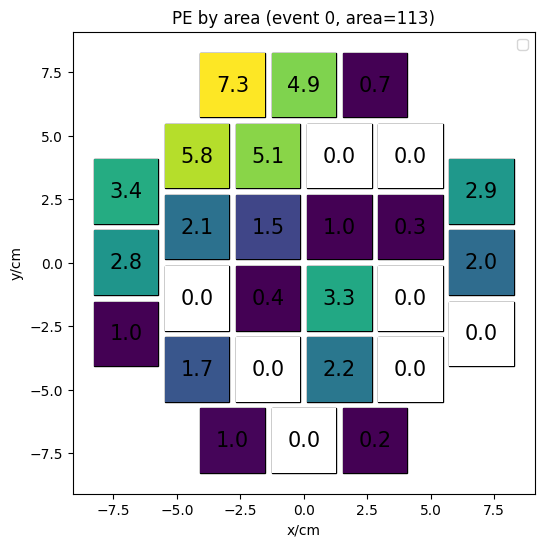

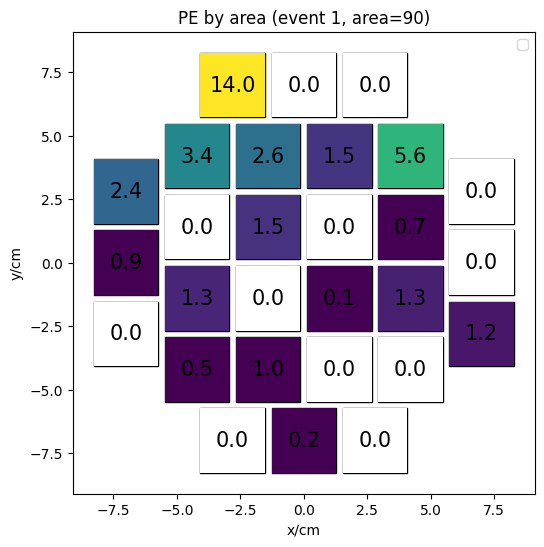

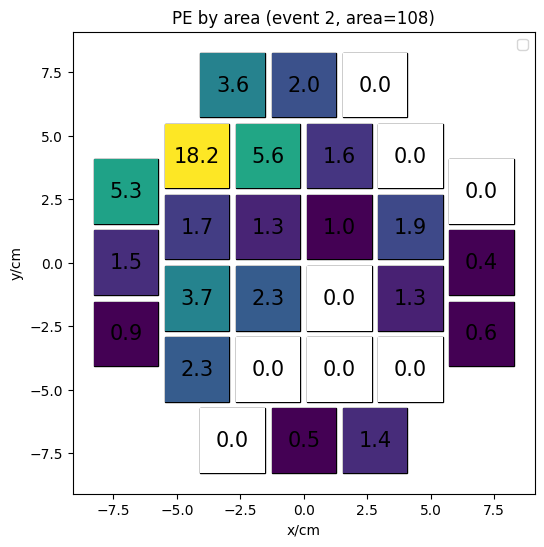

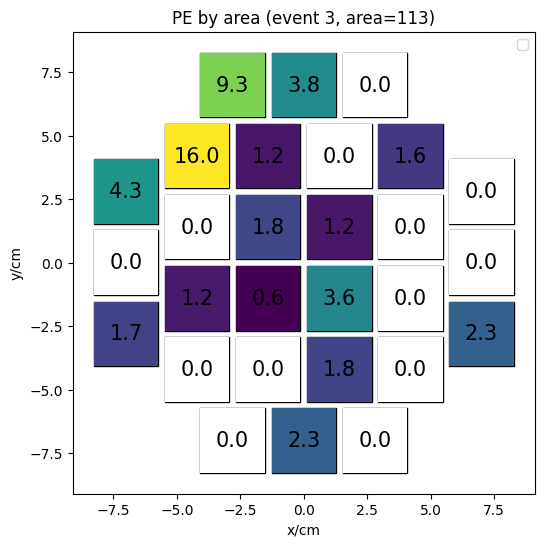

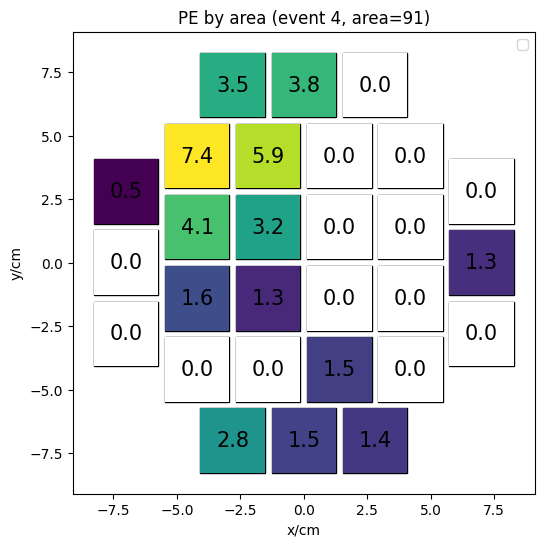

In [6]:
# ============================================================
# 5) 用 pattern_plot 绘制前几个 DE 堆叠事件的 PMT 光斑示例
#    （de_pe_by_area 每行为一个事件的各通道 PE）
# ============================================================
n_show = min(5, len(DE_area))
for i in range(n_show):
    pattern_plot(DE_pe_by_area[i], title=f"PE by area (event {i}, area={DE_area[i]:.0f})")


In [72]:
cevns_ROI_mask = (cevns_area>120) & (cevns_area<300)
DE_ROI_mask = (DE_area>120) & (DE_area<300)

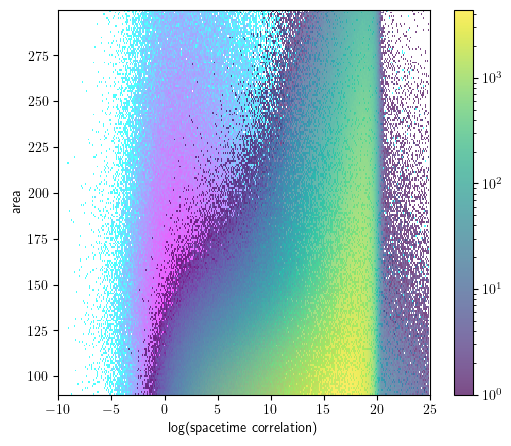

In [70]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

In [74]:
from tqdm import tqdm
def calculate_score(st_cor, area, k_area):
    return k_area * area - np.log(st_cor)


exposure = []

k_area_list = np.arange(-0.1,0.4,0.005)
k_list = []
exposure_k = []
for k in tqdm(k_area_list):
    score_cevns = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area = k)
    score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area = k)
    valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
    valid_score_DE = score_DE[~np.isnan(score_DE)]   
    x = np.percentile(valid_score_DE, 100-0.001)
    exposure_k.append(len(valid_score_cevns[valid_score_cevns>x])/len(valid_score_cevns))
    k_list.append([k,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████| 100/100 [00:26<00:00,  3.72it/s]


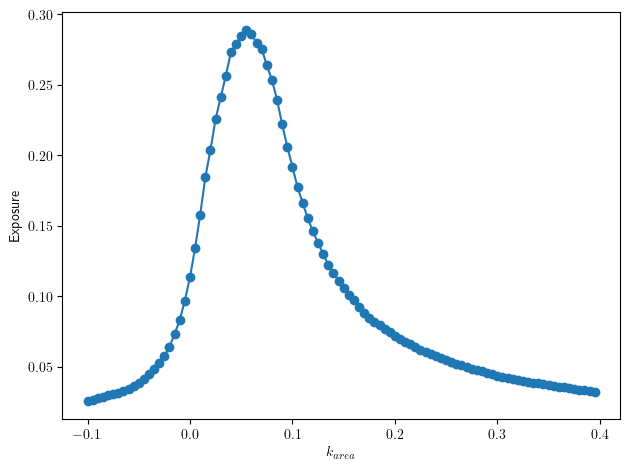

[0.05500000000000013, 8.986912620317279] 0.288419515095881


In [75]:
plt.figure()

plt.plot(k_area_list, exposure_k, marker='o')
plt.xlabel(r"$k_{area}$")
plt.ylabel("Exposure")
plt.tight_layout()

plt.show()

index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_area, b = k_list[index_of_max]
b = -b

In [76]:
def plot_area_spectrum(area, total_time, LXe_mass, bins, **kwargs):
    count, bins = np.histogram(area, bins=bins)
    bin_width = np.diff(bins)
    freq = 86400 * count / (bin_width) / total_time / LXe_mass
    ax = plt.gca()
    ax.stairs(freq, edges=bins, **kwargs)
    ax.set_xlabel('area [PE]')
    ax.set_ylabel('Freq [Count/(Day*kg*PE)]')
    return ax, count, bins

总模拟时间 total_time = 13535.000 s，DE 事件数 = 14057470


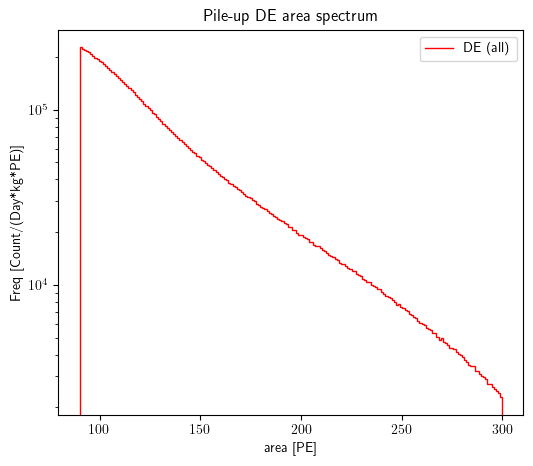

DE rate (total): 505.38 Hz
DE 1年事件数(无cut): 1.594e+10


In [78]:
# ============================================================
# 6) score / cut / DE area 谱（对照原 notebook 末尾分析）
#    注意：原分析同时需要 CEvNS 信号样本；这里仅演示基于 DE 的部分，
#    若你也有对应的 CEvNS 结果可另加载后套用相同公式。
# ============================================================

# ---------- 例子 2：DE area 谱（频率已按 质量*时间 归一化为 Hz/(kg*PE)）----------
LXe_mass = 8.98
print(f"总模拟时间 total_time = {total_time:.3f} s，DE 事件数 = {len(DE_area)}")

fig, ax = plt.subplots(figsize=(6, 5))
bins = np.linspace(90, 300, 200)
plot_area_spectrum(DE_area, total_time, LXe_mass, bins,
                   label='DE (all)', color='red')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')
plt.show()

# 简单统计
print("DE rate (total): {:.2f} Hz".format(len(DE_area[DE_ROI_mask]) / total_time))
print("DE 1年事件数(无cut): {:.3e}".format((len(DE_area[DE_ROI_mask]) / total_time) * 3600 * 24 * 365))


In [79]:
score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area)
score_CEvNS = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area)
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]
score_DE = score_DE[~np.isnan(score_DE)]

In [80]:
thresholds = np.arange(-25, 50, 0.2)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_CEvNS > threshold) / len(score_CEvNS)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

In [81]:
left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.00001):
    index = np.argmax(left_DE_ratios > 1-0.00001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

170


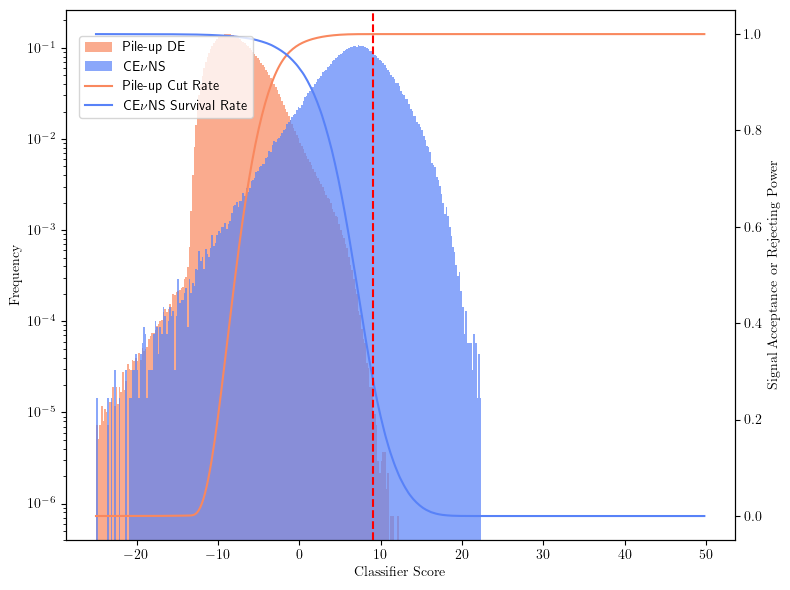

In [82]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-25, 50, 0.2)

ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图


Selected threshold: 9.000
Annual rate: 153777.32 events/yr


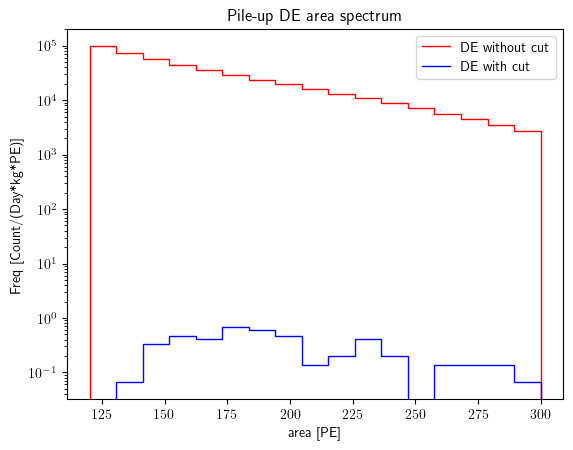

In [83]:
sel_thres = thresholds[index]
print(f"Selected threshold: {sel_thres:.3f}")
DE_cut = score_DE > sel_thres

bins = np.linspace(120,300,18)

plot_area_spectrum(DE_area[DE_ROI_mask], total_time, LXe_mass=8.98, bins=bins, label='DE without cut', color='red')
plot_area_spectrum(DE_area[DE_ROI_mask][DE_cut], total_time, LXe_mass=8.98, bins=bins, label='DE with cut', color='blue')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')

print(f"Annual rate: {(len(DE_area[DE_ROI_mask][DE_cut])/total_time)*3600*24*365:.2f} events/yr")